In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("../data/telecom_inventory.xlsx")
df.head()

,Site_ID,Region,Equipment_Type,Required_Qty,Available_Qty,Ordered_Qty,Unit_Cost,Lead_Time_Days,Order_Date,Shortage,Excess,Clean_Shortage,Clean_Excess,Total_Order_Cost,Critical_Sites
0,Site_0,East,Cable,83,13,51,7652,10,2023-01-01,70,-70,70,0,390252,0
1,Site_1,West,Antenna,26,44,75,9632,5,2023-01-02,-18,18,0,18,722400,0
2,Site_2,North,Antenna,93,70,6,8421,5,2023-01-03,23,-23,23,0,50526,0
3,Site_3,East,Cable,97,113,28,6016,2,2023-01-04,-16,16,0,16,168448,0
4,Site_4,East,Antenna,78,29,10,1769,6,2023-01-05,49,-49,49,0,17690,0


In [3]:
df.info

<bound method DataFrame.info of       Site_ID Region Equipment_Type  Required_Qty  Available_Qty  Ordered_Qty  \
0      Site_0   East          Cable            83             13           51   
1      Site_1   West        Antenna            26             44           75   
2      Site_2  North        Antenna            93             70            6   
3      Site_3   East          Cable            97            113           28   
4      Site_4   East        Antenna            78             29           10   
..        ...    ...            ...           ...            ...          ...   
495  Site_495   East        Antenna            68             51           10   
496  Site_496   East        Antenna            96             33            9   
497  Site_497   West        Antenna            90             80           72   
498  Site_498  North         Router            90             40           77   
499  Site_499   West        Antenna            23            103           76

In [4]:
df.describe()

,Required_Qty,Available_Qty,Ordered_Qty,Unit_Cost,Lead_Time_Days,Order_Date,Shortage,Excess,Clean_Shortage,Clean_Excess,Total_Order_Cost,Critical_Sites
count,500.00000,500.000000,500.000000,500.000000,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,53.26400,63.316000,39.448000,5624.088000,7.696000,2023-09-07 12:00:00,-10.052000,10.052000,12.472000,22.524000,222353.712000,0.144000
min,10.00000,5.000000,0.000000,1016.000000,1.000000,2023-01-01 00:00:00,-107.000000,-90.000000,0.000000,0.000000,0.000000,0.000000
25%,31.00000,34.000000,19.000000,3296.000000,4.000000,2023-05-05 18:00:00,-39.250000,-20.000000,0.000000,0.000000,69669.500000,0.000000
50%,53.00000,63.000000,38.500000,5885.000000,8.000000,2023-09-07 12:00:00,-9.000000,9.000000,0.000000,9.000000,180045.000000,0.000000
75%,76.00000,94.000000,60.000000,7901.750000,11.000000,2024-01-10 06:00:00,20.000000,39.250000,20.000000,39.250000,325014.500000,0.000000
max,99.00000,119.000000,79.000000,9984.000000,14.000000,2024-05-14 00:00:00,90.000000,107.000000,90.000000,107.000000,743660.000000,1.000000
std,26.45998,33.429076,23.618785,2647.252331,4.027907,NaN,42.102239,42.102239,20.597615,28.024492,178578.764776,0.351441


In [5]:
df.isnull().sum()

Site_ID             0
Region              0
Equipment_Type      0
Required_Qty        0
Available_Qty       0
Ordered_Qty         0
Unit_Cost           0
Lead_Time_Days      0
Order_Date          0
Shortage            0
Excess              0
Clean_Shortage      0
Clean_Excess        0
Total_Order_Cost    0
Critical_Sites      0
dtype: int64

In [6]:
df.groupby("Region")["Clean_Shortage"].sum().sort_values(ascending=False)

Region
West     1750
North    1668
East     1467
South    1351
Name: Clean_Shortage, dtype: int64

In [7]:
df.groupby("Region")["Clean_Excess"].sum().sort_values(ascending=False)

Region
West     3387
East     2854
North    2603
South    2418
Name: Clean_Excess, dtype: int64

In [8]:
df.groupby("Equipment_Type")["Total_Order_Cost"].sum().sort_values(ascending=False)

Equipment_Type
Antenna    40082112
Router     38359852
Cable      32734892
Name: Total_Order_Cost, dtype: int64

In [9]:
df[(df["Clean_Shortage"] > 0) & (df["Lead_Time_Days"] > 10)].shape[0]

72

In [10]:
summary = f"""
Telecom Inventory Analysis Summary

1. Region with highest shortage: West ({df.groupby('Region')['Clean_Shortage'].sum().sort_values(ascending=False).index[0]}) with {df.groupby('Region')['Clean_Shortage'].sum().sort_values(ascending=False).iloc[0]} units
2. Region with highest excess: West ({df.groupby('Region')['Clean_Excess'].sum().sort_values(ascending=False).index[0]}) with {df.groupby('Region')['Clean_Excess'].sum().sort_values(ascending=False).iloc[0]} units
3. Equipment type with highest total order cost: {df.groupby('Equipment_Type')['Total_Order_Cost'].sum().sort_values(ascending=False).index[0]} with cost {df.groupby('Equipment_Type')['Total_Order_Cost'].sum().sort_values(ascending=False).iloc[0]}
4. Number of critical sites with shortage and lead time > 10 days: {df[(df['Clean_Shortage'] > 0) & (df['Lead_Time_Days'] > 10)].shape[0]}
"""

print(summary)


Telecom Inventory Analysis Summary

1. Region with highest shortage: West (West) with 1750 units
2. Region with highest excess: West (West) with 3387 units
3. Equipment type with highest total order cost: Antenna with cost 40082112
4. Number of critical sites with shortage and lead time > 10 days: 72



In [11]:
highest_shortage_region = df.groupby("Region")["Clean_Shortage"].sum().sort_values(ascending=False).index[0]
highest_shortage_value = df.groupby("Region")["Clean_Shortage"].sum().sort_values(ascending=False).iloc[0]

highest_excess_region = df.groupby("Region")["Clean_Excess"].sum().sort_values(ascending=False).index[0]
highest_excess_value = df.groupby("Region")["Clean_Excess"].sum().sort_values(ascending=False).iloc[0]

highest_cost_equipment = df.groupby("Equipment_Type")["Total_Order_Cost"].sum().sort_values(ascending=False).index[0]
highest_cost_value = df.groupby("Equipment_Type")["Total_Order_Cost"].sum().sort_values(ascending=False).iloc[0]

critical_sites = df[(df["Clean_Shortage"] > 0) & (df["Lead_Time_Days"] > 10)].shape[0]

insight = f"""
AI Business Insight Report

1. {highest_shortage_region} region has the highest shortage of {highest_shortage_value} units, indicating a major demand-supply mismatch.
2. {highest_excess_region} region also has the highest excess inventory of {highest_excess_value} units, suggesting inefficient stock allocation across sites.
3. {highest_cost_equipment} is the most expensive equipment category with a total order cost of {highest_cost_value}, making it the biggest contributor to inventory spend.
4. There are {critical_sites} critical sites with both shortage and lead times above 10 days, which increases the risk of operational delays.
5. Recommendation: Improve site-level inventory balancing in the West region, prioritize replenishment for critical sites, and optimize antenna ordering to control costs.
"""

print(insight)


AI Business Insight Report

1. West region has the highest shortage of 1750 units, indicating a major demand-supply mismatch.
2. West region also has the highest excess inventory of 3387 units, suggesting inefficient stock allocation across sites.
3. Antenna is the most expensive equipment category with a total order cost of 40082112, making it the biggest contributor to inventory spend.
4. There are 72 critical sites with both shortage and lead times above 10 days, which increases the risk of operational delays.
5. Recommendation: Improve site-level inventory balancing in the West region, prioritize replenishment for critical sites, and optimize antenna ordering to control costs.



In [12]:
import matplotlib.pyplot as plt

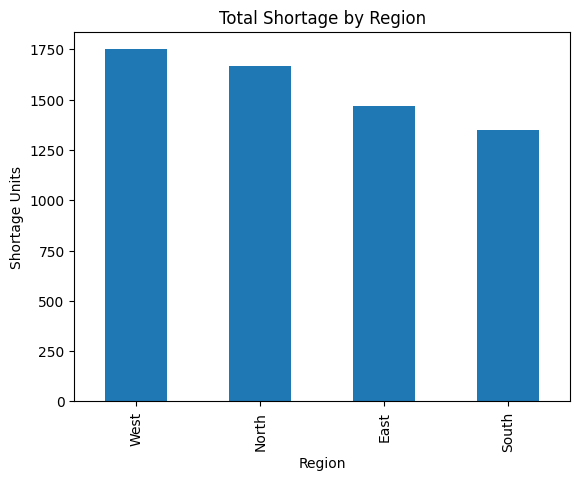

In [15]:
df.groupby("Region")["Clean_Shortage"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Total Shortage by Region")
plt.xlabel("Region")
plt.ylabel("Shortage Units")
plt.show()

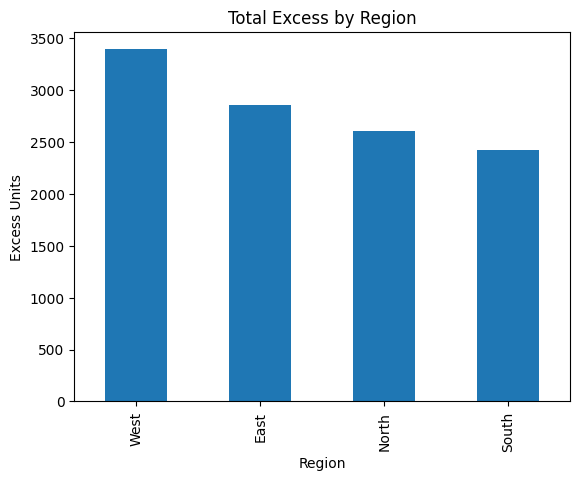

In [17]:
df.groupby("Region")["Clean_Excess"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Total Excess by Region")
plt.xlabel("Region")
plt.ylabel("Excess Units")
plt.show()

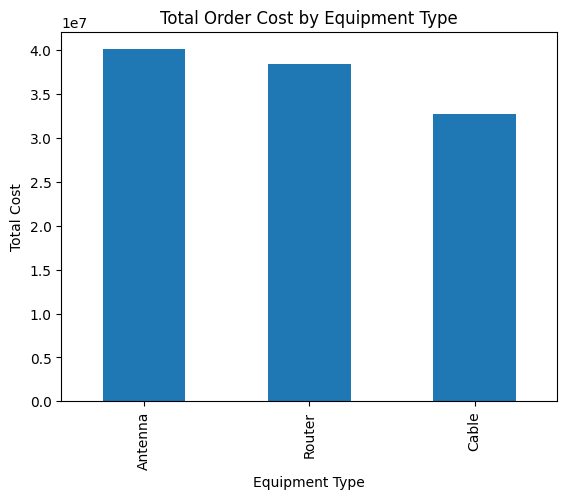

In [18]:
df.groupby("Equipment_Type")["Total_Order_Cost"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Total Order Cost by Equipment Type")
plt.xlabel("Equipment Type")
plt.ylabel("Total Cost")
plt.show()